Pixel-shuffling
====

This notebook presents how to use the cleaned code for Pixel-shuffling. See Section 5 of the Image Obfuscation for Privacy-Preserving Machine Learning report for more details.

In [1]:

import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt

We import the additional code of pixelshuffling where most of the logic is.

In [2]:

import util
import exp_models
import lambdas
import pixelshuffling as ps


We insert this code snippet to remove pseudorandomness. NN training results may still vary due to CUDA being enabled.

In [3]:
# Reproducibility
SEED = 2019

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

We import our dataset and set our model

In [4]:
base_trainset, base_testset = util.get_sets("CIFAR100")
model_getter = exp_models.resnet18_100classes

Files already downloaded and verified
Files already downloaded and verified


However, we need to wrap the base datasets into our PixelShuffler class, extending torch.utils.data.Dataset, which will shuffle our images for us

In [5]:
transform = torchvision.transforms.transforms.Compose(
    [torchvision.transforms.transforms.ToTensor()])
trainset = ps.PixelShuffler(base_trainset, 2019, transform=transform)
testset = ps.PixelShuffler(base_testset, 2019, 
    preset_masks=trainset.pmix_masks,
    transform=transform)

Let's take a look at the first original and the first element of the PixelShuffler set:

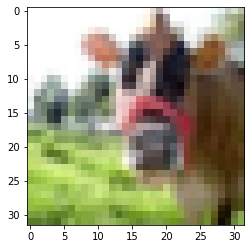

In [6]:
util.show_np_arr(trainset.ingredients[0])

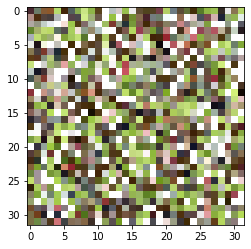

In [7]:
util.show_np_arr(trainset[0][0])

We define the dataloaders and take a look at the dataloader which should be shuffled:

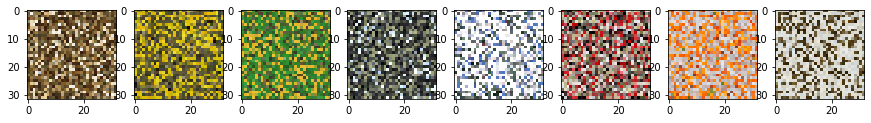

In [8]:
trainloader, N_BATCHES_TRAIN = util.get_loader(trainset, shuffle=True)
testloader, N_BATCHES_TEST = util.get_loader(testset, shuffle=False)
util.show_loader_cf(trainloader)

We load lambdas, in our example we will use the sweetspot lambda only, with $N=4$.

This will be used to perform Pixel-shuffing+mixup, as is described in the report, subsection 5.4.

If we want to perform Pixel-shuffling **only**, we can use
$$\hat{\lambda}_{\textbf{nomix}} : \lambda_i = 1\{i = 0\}$$
which will yield equivalent results.

[0.75     0.1875   0.046875 0.015625]


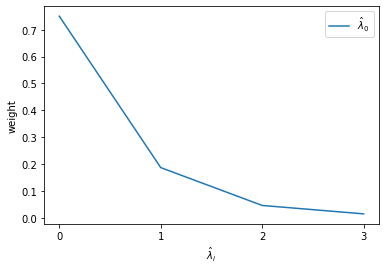

In [9]:
LAMBDAS = lambdas.sweetspot(4)
lambdas.show(LAMBDAS)

We then use *util.perform_experiment* as in Fixed-mixup.

In [10]:

RESULTS_FNAME = "deleteme0"
with open("results/"+RESULTS_FNAME, "w"):pass
test_accs, train_losses, val_losses, images_mx, ys, perms = util.perform_experiment(
    trainloader,
    testloader,
    lambdas=LAMBDAS,
    results_fname=RESULTS_FNAME,
    N_BATCHES_TRAIN=N_BATCHES_TRAIN,
    model_getter=model_getter,
    n_epochs=5,
    n_batches=100
)


Saving results in deleteme0
Trying lambda= [0.75     0.1875   0.046875 0.015625]
Performing n-mixup with N-mix: 4
Epoch[1/5]
train loss:4.6722 Epoch[1/5] Batch[0/500]
train loss:4.5223 Epoch[1/5] Batch[50/500]
train loss:4.3224 Epoch[1/5] Batch[100/500]
val loss:4.0783 Epoch[1/5]
val acc:8.0000 Epoch[1/5]
Epoch[2/5]
train loss:4.3361 Epoch[2/5] Batch[0/500]
train loss:4.3140 Epoch[2/5] Batch[50/500]
train loss:4.2221 Epoch[2/5] Batch[100/500]
val loss:4.0422 Epoch[2/5]
val acc:7.0000 Epoch[2/5]
Epoch[3/5]
train loss:4.0576 Epoch[3/5] Batch[0/500]
train loss:4.2461 Epoch[3/5] Batch[50/500]
train loss:4.1832 Epoch[3/5] Batch[100/500]
val loss:3.8953 Epoch[3/5]
val acc:12.0000 Epoch[3/5]
Epoch[4/5]
train loss:4.1782 Epoch[4/5] Batch[0/500]
train loss:4.1558 Epoch[4/5] Batch[50/500]
train loss:4.0850 Epoch[4/5] Batch[100/500]
val loss:3.7639 Epoch[4/5]
val acc:8.0000 Epoch[4/5]
Epoch[5/5]
train loss:4.0542 Epoch[5/5] Batch[0/500]
train loss:4.1056 Epoch[5/5] Batch[50/500]
train loss:4.0685

We can see what the last batch of samples looked like through *images_mx*:

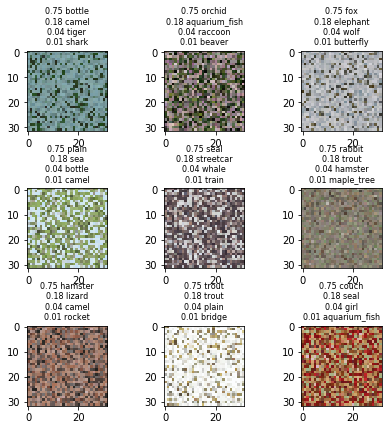

In [11]:

fig, axes = plt.subplots(3, 3, figsize=(6, 6))
plt.tight_layout(pad=2)
for j in range(3):
    for i in range(3):
        util.show_np_arr(images_mx.cpu()[j*3+i], ax=axes[j, i])
        titles = [
            str(LAMBDAS[0][k])[:4] + " " + trainset.classes[ys[k][j*3+i]]
            for k in range(LAMBDAS[0].shape[0])
        ]
        axes[j, i].set_title('\n'.join(titles), fontsize=8, rotation=0)